Name: Sapan Kumar Pandey
Roll : G25AIT1154
Subject: NLU(Natural Language Understanding asiggnment2)

In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q pandas numpy matplotlib tqdm nltk bert-score scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.7 MB/s eta 0:00:00


In [ ]:
import os
import re
import time
import zipfile
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

from bert_score import score
from nltk.translate.bleu_score import corpus_bleu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [3]:
import zipfile

zip_path = "dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

print(sorted(os.listdir("data")))

['__MACOSX', 'dataset']


In [5]:
import pandas as pd

train_sa = pd.read_csv("data/dataset/train_sa_10000.csv")
train_en = pd.read_csv("data/dataset/train_en_10000.csv")

dev_sa = pd.read_csv("data/dataset/dev_sa_1000.csv")
dev_en = pd.read_csv("data/dataset/dev_en_1000.csv")

test_sa = pd.read_csv("data/dataset/test_sa_1000.csv")
test_en = pd.read_csv("data/dataset/test_en_1000.csv")

In [6]:
train = pd.merge(train_sa, train_en, on="Source_id")
dev = pd.merge(dev_sa, dev_en, on="Source_id")
test = pd.merge(test_sa, test_en, on="Source_id")

In [7]:
print("Training Samples :", len(train))
print("Validation Samples :", len(dev))
print("Testing Samples :", len(test))

train.head()

Training Samples : 10000
Validation Samples : 1000
Testing Samples : 1000


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [8]:
import re
import pandas as pd

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

# Define train, dev, and test dataframes before use
train = pd.merge(train_sa, train_en, on="Source_id")
dev = pd.merge(dev_sa, dev_en, on="Source_id")
test = pd.merge(test_sa, test_en, on="Source_id")

for df in [train, dev, test]:
    df["Sentence_sa"] = df["Sentence_sa"].apply(clean_text)
    df["Sentence_en"] = df["Sentence_en"].apply(clean_text)

print("Text preprocessing completed.")

Text preprocessing completed.


In [9]:
for df in [train, dev, test]:
    df["sa_tokens"] = df["Sentence_sa"].apply(lambda x: x.split())
    df["en_tokens"] = df["Sentence_en"].apply(lambda x: x.split())

train[["sa_tokens", "en_tokens"]].head()

,sa_tokens,en_tokens
0,"[""ctrl,, s, नुत्वा, रक्षन्तु।""]","[save, it, with, ctrl,, s.]"
1,"[गुरुः, छात्रान्, एकवारं, पाठयति, ।]","[teacher, will, teach, the, students, only, on..."
2,"[चित्रचालनमिदं, पुनः, कर्तुं, मया, अस्याः, राश...","[to, recreate, this, animation,, i, have, to, ..."
3,"[वयं, colors, विकल्पं, तस्योपरि, नोदनेन, चिनुम...","[i, will, choose, colors, options, by, clickin..."
4,"[""अत्र, कानिचन, उदाहरणानि, पश्याम:-, एक:, पर्व...","[""see, the, example, here, -, one, mountain,, ..."


In [10]:
from collections import Counter

SPECIAL_TOKENS = ["<pad>", "<unk>", "<sos>", "<eos>"]

def build_vocab(token_lists, min_freq=2):
    counter = Counter()

    for sentence in token_lists:
        counter.update(sentence)

    vocab = SPECIAL_TOKENS.copy()

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab.append(word)

    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}

    return word2idx, idx2word

# Ensure 'sa_tokens' and 'en_tokens' columns exist in train dataframe
# This step was originally in SHwdTPh3gifU but seems to be missing when this cell executes.
if "sa_tokens" not in train.columns:
    train["sa_tokens"] = train["Sentence_sa"].apply(lambda x: x.split())
if "en_tokens" not in train.columns:
    train["en_tokens"] = train["Sentence_en"].apply(lambda x: x.split())

sa_word2idx, sa_idx2word = build_vocab(train["sa_tokens"])
en_word2idx, en_idx2word = build_vocab(train["en_tokens"])

print("Sanskrit Vocabulary Size:", len(sa_word2idx))
print("English Vocabulary Size:", len(en_idx2word))

Sanskrit Vocabulary Size: 8379
English Vocabulary Size: 7072


In [11]:
MAX_LEN = 50

def encode(tokens, vocab):
    ids = [vocab["<sos>"]]

    for token in tokens:
        ids.append(vocab.get(token, vocab["<unk>"]))

    ids.append(vocab["<eos>"])

    ids = ids[:MAX_LEN]

    while len(ids) < MAX_LEN:
        ids.append(vocab["<pad>"])

    return ids

# Ensure 'sa_tokens' and 'en_tokens' columns exist in all dataframes
for df in [train, dev, test]:
    if "sa_tokens" not in df.columns:
        df["sa_tokens"] = df["Sentence_sa"].apply(lambda x: x.split())
    if "en_tokens" not in df.columns:
        df["en_tokens"] = df["Sentence_en"].apply(lambda x: x.split())

for df in [train, dev, test]:
    df["src"] = df["sa_tokens"].apply(lambda x: encode(x, sa_word2idx))
    df["trg"] = df["en_tokens"].apply(lambda x: encode(x, en_word2idx))

print("Encoding completed.")

Encoding completed.


In [12]:
from torch.utils.data import Dataset

class TranslationDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        src = torch.tensor(
            self.df.iloc[idx]["src"],
            dtype=torch.long
        )

        trg = torch.tensor(
            self.df.iloc[idx]["trg"],
            dtype=torch.long
        )

        return src, trg

In [13]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataset = TranslationDataset(train)
dev_dataset = TranslationDataset(dev)
test_dataset = TranslationDataset(test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(dev_loader))
print("Test Batches :", len(test_loader))

Train Batches : 157
Validation Batches : 16
Test Batches : 16


In [14]:
INPUT_DIM = len(sa_word2idx)
OUTPUT_DIM = len(en_word2idx)

EMBED_DIM = 256
HIDDEN_DIM = 512

NUM_LAYERS = 2

DROPOUT = 0.3

PAD_IDX = 0

In [15]:
import torch.nn as nn

class Encoder(nn.Module):

    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers, dropout):

        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)

        self.dropout = nn.Dropout(dropout)

        self.rnn = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, src):

        embedded = self.dropout(self.embedding(src))

        outputs, (hidden, cell) = self.rnn(embedded)

        return outputs, hidden, cell

In [16]:
class Attention(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)

        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        hidden = hidden[-1].unsqueeze(1)

        hidden = hidden.repeat(1, encoder_outputs.shape[1], 1)

        energy = torch.tanh(
            self.attn(
                torch.cat((hidden, encoder_outputs), dim=2)
            )
        )

        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=1)

In [17]:
class Decoder(nn.Module):

    def __init__(self,
                 output_dim,
                 emb_dim,
                 hidden_dim,
                 num_layers,
                 dropout,
                 attention):

        super().__init__()

        self.output_dim = output_dim

        self.attention = attention

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=PAD_IDX
        )

        self.dropout = nn.Dropout(dropout)

        self.rnn = nn.LSTM(
            emb_dim + hidden_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self,
                input,
                hidden,
                cell,
                encoder_outputs):

        input = input.unsqueeze(1)

        embedded = self.dropout(
            self.embedding(input)
        )

        attention = self.attention(
            hidden,
            encoder_outputs
        )

        context = torch.bmm(
            attention.unsqueeze(1),
            encoder_outputs
        )

        rnn_input = torch.cat(
            (embedded, context),
            dim=2
        )

        output, (hidden, cell) = self.rnn(
            rnn_input,
            (hidden, cell)
        )

        prediction = self.fc(output.squeeze(1))

        return prediction, hidden, cell

In [18]:
import random

class Seq2Seq(nn.Module):

    def __init__(self,
                 encoder,
                 decoder,
                 device):

        super().__init__()

        self.encoder = encoder

        self.decoder = decoder

        self.device = device

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = trg.shape[0]

        trg_len = trg.shape[1]

        vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            vocab_size
        ).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        input = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden, cell = self.decoder(
                input,
                hidden,
                cell,
                encoder_outputs
            )

            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio

            top1 = output.argmax(1)

            input = trg[:, t] if teacher_force else top1

        return outputs

In [19]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

attention = Attention(HIDDEN_DIM)

encoder = Encoder(
    INPUT_DIM,
    EMBED_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

decoder = Decoder(
    OUTPUT_DIM,
    EMBED_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT,
    attention
)

model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8379, 256, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn): Linear(in_features=1024, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(7072, 256, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): LSTM(768, 512, num_layers=2, batch_first=True, dropout=0.3)
    (fc): Linear(in_features=512, out_features=7072, bias=True)
  )
)


In [20]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
from tqdm import tqdm

def train(model, loader, optimizer, criterion):

    model.train()

    epoch_loss = 0

    for src, trg in tqdm(loader):

        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, trg)

        output = output[:, 1:].reshape(-1, OUTPUT_DIM)

        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [22]:
def evaluate(model, loader, criterion):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src, trg in loader:

            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, 0)

            output = output[:, 1:].reshape(-1, OUTPUT_DIM)

            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [23]:
import time

EPOCHS = 5

train_losses = []
valid_losses = []

best_valid = float("inf")

for epoch in range(EPOCHS):

    start = time.time()

    train_loss = train(
        model,
        train_loader,
        optimizer,
        criterion
    )

    valid_loss = evaluate(
        model,
        dev_loader,
        criterion
    )

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid:

        best_valid = valid_loss

        torch.save(model.state_dict(), "best_model.pt")

    end = time.time()

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Time : {end-start:.2f} seconds\n")

100%|██████████| 157/157 [00:59<00:00,  2.63it/s]


Epoch 1/5
Train Loss : 6.3295
Valid Loss : 5.7628
Time : 62.17 seconds



100%|██████████| 157/157 [01:03<00:00,  2.45it/s]


Epoch 2/5
Train Loss : 6.0093
Valid Loss : 5.6824
Time : 66.80 seconds



100%|██████████| 157/157 [01:03<00:00,  2.45it/s]


Epoch 3/5
Train Loss : 5.8520
Valid Loss : 5.5890
Time : 66.63 seconds



100%|██████████| 157/157 [01:04<00:00,  2.44it/s]


Epoch 4/5
Train Loss : 5.6720
Valid Loss : 5.4953
Time : 67.09 seconds



100%|██████████| 157/157 [01:04<00:00,  2.43it/s]


Epoch 5/5
Train Loss : 5.4994
Valid Loss : 5.4353
Time : 67.30 seconds



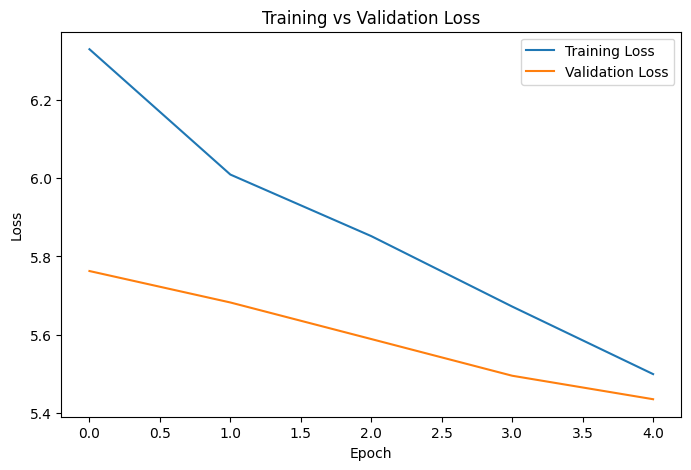

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [26]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [27]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters : 16513696
Trainable Parameters : 16513696


In [28]:
start = time.time()

with torch.no_grad():
    for src, trg in test_loader:
        src = src.to(device)
        trg = trg.to(device)
        _ = model(src, trg, 0)

end = time.time()

print("Inference Time (seconds):", end - start)

Inference Time (seconds): 2.6578073501586914


In [29]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters : 16513696
Trainable Parameters : 16513696


In [30]:
def translate_sentence(sentence, model,
                       sa_word2idx,
                       en_idx2word,
                       device,
                       max_len=50):

    model.eval()

    tokens = sentence.strip().split()

    src = encode(tokens, sa_word2idx)

    src_tensor = torch.LongTensor(src).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    trg_indexes = [en_word2idx["<sos>"]]

    for i in range(max_len):

        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)

        with torch.no_grad():
            output, hidden, cell = model.decoder(
                trg_tensor,
                hidden,
                cell,
                encoder_outputs
            )

        pred_token = output.argmax(1).item()

        trg_indexes.append(pred_token)

        if pred_token == en_word2idx["<eos>"]:
            break

    trg_tokens = []

    for idx in trg_indexes[1:]:

        word = en_idx2word[idx]

        if word == "<eos>":
            break

        trg_tokens.append(word)

    return " ".join(trg_tokens)

In [31]:
sample = "रामः वनं गच्छति"

prediction = translate_sentence(
    sample,
    model,
    sa_word2idx,
    en_idx2word,
    device
)

print("Sanskrit :", sample)
print("Prediction:", prediction)

Sanskrit : रामः वनं गच्छति
Prediction: you <unk>


In [32]:
print(type(dev))
print(type(test))

print(dev[:3])
print(test[:3])

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
   Source_id                                        Sentence_sa  \
0          1                                         ते वीराः ।   
1          2  'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां क...   
2          3  ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर...   

                                         Sentence_en  \
0                               those are brave men.   
1  infinite loop can cause the system to become u...   
2  "and they spit upon him, and took the reed, an...   

                                           sa_tokens  \
0                                     [ते, वीराः, ।]   
1  ['इन्फ़ैनेट्, लूप्', इतीदं, व्यवस्थां, निरुत्त...   
2  [ततस्तस्य, गात्रे, निष्ठीवं, दत्वा, तेन, वेत्र...   

                                           en_tokens  \
0                          [those, are, brave, men.]   
1  [infinite, loop, can, cause, the, system, to, ...   
2  ["and, they, spit, upon, him,, and

In [33]:
sample = dev.iloc[0]["Sentence_sa"]

prediction = translate_sentence(
    sample,
    model,
    sa_word2idx,
    en_idx2word,
    device
)

print("Sanskrit:")
print(sample)

print()

print("Prediction:")
print(prediction)

print()

print("Reference:")
print(dev.iloc[0]["Sentence_en"])

Sanskrit:
ते वीराः ।

Prediction:
you <unk>

Reference:
those are brave men.


In [34]:
from nltk.translate.bleu_score import corpus_bleu

references = []
predictions = []

for _, row in dev.iterrows():

    pred = translate_sentence(
        row["Sentence_sa"],
        model,
        sa_word2idx,
        en_idx2word,
        device
    )

    references.append([row["Sentence_en"].split()])
    predictions.append(pred.split())

bleu = corpus_bleu(references, predictions)

print("BLEU Score:", bleu)

BLEU Score: 0.002919898098670178


In [35]:
!pip -q install bert-score

from bert_score import score

preds = []
refs = []

for _, row in dev.iterrows():

    pred = translate_sentence(
        row["Sentence_sa"],
        model,
        sa_word2idx,
        en_idx2word,
        device
    )

    preds.append(pred)
    refs.append(row["Sentence_en"])

P, R, F1 = score(
    preds,
    refs,
    lang="en",
    verbose=True
)

print("BERT Precision :", P.mean().item())
print("BERT Recall    :", R.mean().item())
print("BERT F1 Score  :", F1.mean().item())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.7 MB/s eta 0:00:00


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/20 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 8.24 seconds, 121.43 sentences/sec
BERT Precision : 0.7507842183113098
BERT Recall    : 0.8183308839797974
BERT F1 Score  : 0.7827749252319336


In [36]:
predictions = []

for _, row in test.iterrows():

    pred = translate_sentence(
        row["Sentence_sa"],
        model,
        sa_word2idx,
        en_idx2word,
        device
    )

    predictions.append(pred)

submission = pd.DataFrame({
    "Source_id": test["Source_id"],
    "Sentence_en": predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())

print("\nsubmission.csv created successfully!")

   Source_id                                        Sentence_en
0          1                    <unk> the the <unk> <unk> <unk>
1          2  <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk...
2          3  <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk...
3          4  <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk...
4          5  "and he said unto the <unk> <unk> <unk> <unk> ...

submission.csv created successfully!
